# (AI-Scientific Image Forgery)
- **Kaggle Competition Data Ingestion and EDA Notebook**
  - Log into Kaggle
  - Go to setttings
  - locate and create new kaggle API key


# Research:
  - feature based and block based algorithms
  - feature based: SIFT and SURF algorithms


---


## Masks
-  Copy-Move Forgery Detection:(Localization and Classification)
- We use the mask to detect the localization of the forgery, after all saying an image is forged doesn't help unless we can point out where the forgery happens.
- The mask is the ground truth telling the model where the copy-move occurred.


**Pasted regions share:**

1. similar local descriptors

2. similar noise patterns

3. similar frequency/texture structure

4. unnatural symmetry with another region in the image

***The model learns:***

> “Pixels that look very similar to another area AND match the mask are copy-moved.”

*Without a mask, the model has no idea which pixels are forged, so it cannot learn these patterns.*
The goal is to train a model to detect and predict a mask that highlights the suspicious areas.


---
**KEY POINT**
>Normally we train a model to detect fake or real classes. This is not enough and training given only labels does not help identify the localized patterns, generates bias within classification, and trains global level clues instead of pixel level differences

---

Image Encoder:
  Encoder functions:
(Extracting the meaning of the image)

    - Detect edges, textures, patterns
    - Compress spatial resolution (downsample)
    - Increase channel depth (richer features)
    - Capture what is in the image (content)
DINOv2 encoder is a vision transformer encoder.

Image Decoder:
  Decoder functions:
(constructing a pixel-level prediction from abstract features)

    - Increase resolution
    - Produce dense pixel-by-pixel predictions
    - Output segmentation masks or heatmaps
    - Return information to original image size

Encoder learns what the image is, Decoder learns where it is.

---

## Segmenation models:
  - "which pixel belongs to which class?"
  - this model will output the forgery mask, a 0 pixel for original and 1 for forged regions.
  - encoder -> decoder -> mask output.
  - Types of encoders, CNN encoder, Transformer encoder, hybrid architectures.
  - CNN architectures are good and identifying local patterns.
  - Vision Transformers, good for global attention. helps identify long range relationship.
  - We can use a combination of Vision Transformer encoder and CNN decoder to combine the strengths and gather precision on local and global regions.

### ViT (Vision Transformer)
  - Looks at the entire image at once unlike a CNN architecture.
  - Tokenizes the image into patches, learns via the self attention mechanism.
  - each image patch is similar to a token in a regular transformer.
  - self attention allows the patches to identify relationships and give context awareness and spacial awareness.


### Data API


In [22]:
#upload your kaggle.json API key from kaggle.
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"calebmesiti","key":"0b81013a36661ef72e7505234ebf6932"}'}

In [23]:
#Calling Kaggle API for Competition Dataset
!mkdir -p /root/.config/.kaggle
!mv kaggle.json /root/.config/.kaggle

In [30]:
!chmod 600 /root/.config/kaggle/kaggle.json

chmod: cannot access '/root/.config/kaggle/kaggle.json': No such file or directory


In [29]:

!kaggle competitions download -c recodai-luc-scientific-image-forgery-detection
!unzip /content/recodai-luc-scientific-image-forgery-detection.zip

401 Client Error: Unauthorized for url: https://www.kaggle.com/api/v1/competitions/data/download-all/recodai-luc-scientific-image-forgery-detection
unzip:  cannot find or open /content/recodai-luc-scientific-image-forgery-detection.zip, /content/recodai-luc-scientific-image-forgery-detection.zip.zip or /content/recodai-luc-scientific-image-forgery-detection.zip.ZIP.


### Library Imports

In [ ]:
#basic imports required to get started
import torch
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms, utils
import pandas as pd
import os
import torch.nn as nn
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2 as cv  #open cv, good place to start image process, object detection, heat maps, etc.

## Exploratory Analysis (planning phase)
- Check images
- Identify simple patterns, transformation requirements.
- Prepare and Identify a plan.




In [ ]:
#Directories:
FORGED_DIR = "/content/train_images/forged"
AUTHENTIC_DIR = "/content/train_images/authentic"
MASK_DIR = "/content/train_masks"
TEST_DIR = "/content/test_images"
SUBM_DIR = "/content/sample_submission.csv"

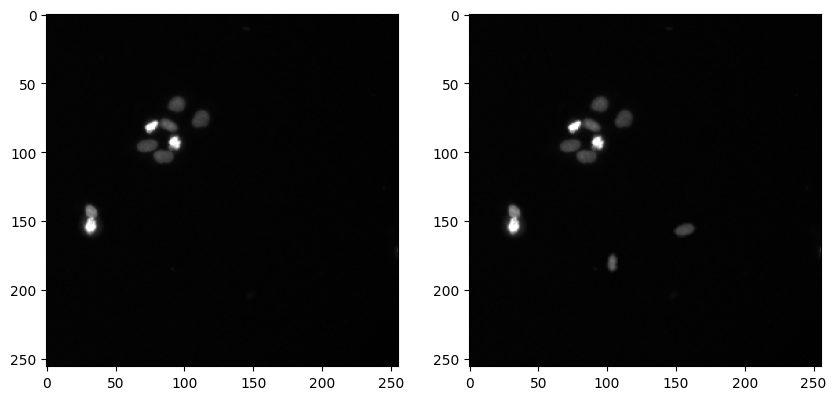

In [ ]:
#visualize
test_img = "25458.png"
mask = f"{test_img.split(".")[0]}.npy"

real_img_pth = os.path.join(AUTHENTIC_DIR, test_img)
fake_img_pth = os.path.join(FORGED_DIR, test_img)

real_img = cv.imread(real_img_pth, cv.IMREAD_GRAYSCALE)
fake_img = cv.imread(fake_img_pth, cv.IMREAD_GRAYSCALE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(real_img,cmap='gray')
ax2.imshow(fake_img,cmap='gray')


plt.show()

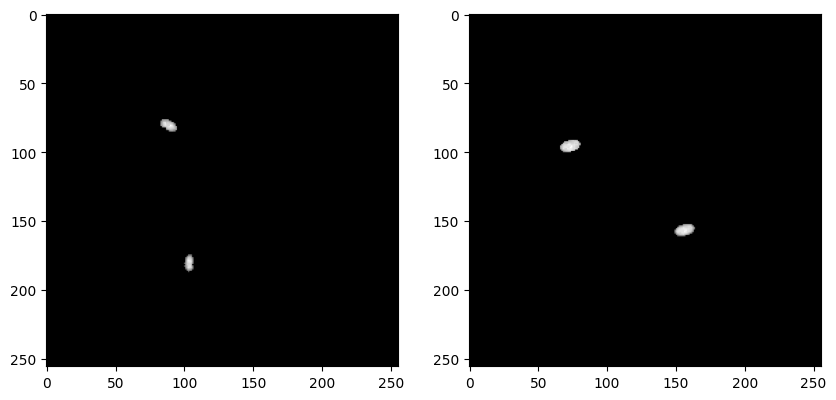

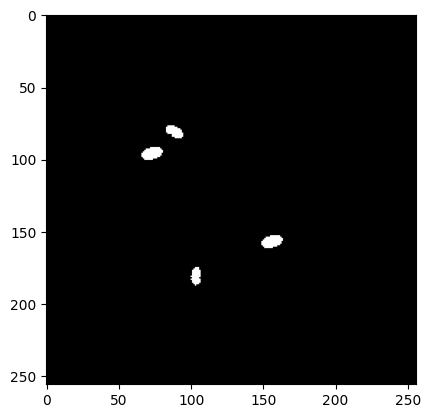

In [ ]:
img_mask_pth = os.path.join(MASK_DIR, mask)

#mask array
img_mask = np.load(img_mask_pth)
img_mask.shape

#lets take the first mask
img_mask_1 = img_mask[0]
img_mask_2 = img_mask[1]

masked_image_1 = cv.bitwise_and(fake_img, fake_img, mask = img_mask_1)
masked_image_2 = cv.bitwise_and(fake_img, fake_img, mask=img_mask_2)

#here we have two masks
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(masked_image_1, cmap="gray")
ax2.imshow(masked_image_2, cmap="gray")
plt.show()


#lets try and merge the 2 masks into 1
full_mask = np.max(img_mask, axis=0)
#takes the max value collapsing to the first dimension.
plt.imshow(full_mask, cmap="gray")



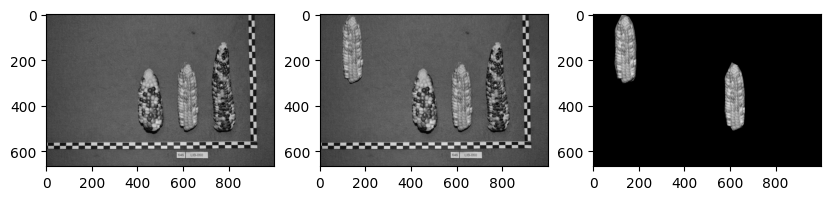

In [ ]:
from ast import For
#visualize another img
test_img_pth = "10030.png"
mask = f"{test_img_pth.split(".")[0]}.npy"
img_mask_pth = os.path.join(MASK_DIR, mask) #10030.npy


real_img = os.path.join(AUTHENTIC_DIR, test_img_pth)
fake_img = os.path.join(FORGED_DIR, test_img_pth)
mask_array = np.load(img_mask_pth).squeeze()


real_img = cv.imread(real_img, cv.IMREAD_GRAYSCALE)
fake_img = cv.imread(fake_img, cv.IMREAD_GRAYSCALE)
masked_img = cv.bitwise_and(fake_img, fake_img, mask=mask_array)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))
ax1.imshow(real_img, cmap="gray")
ax2.imshow(fake_img, cmap="gray")
ax3.imshow(masked_img, cmap="gray")
plt.show()


In [ ]:
real_img.shape

(666, 1000)

# Transformation Tests
- Histogram Equalization
- LCM CLAHE

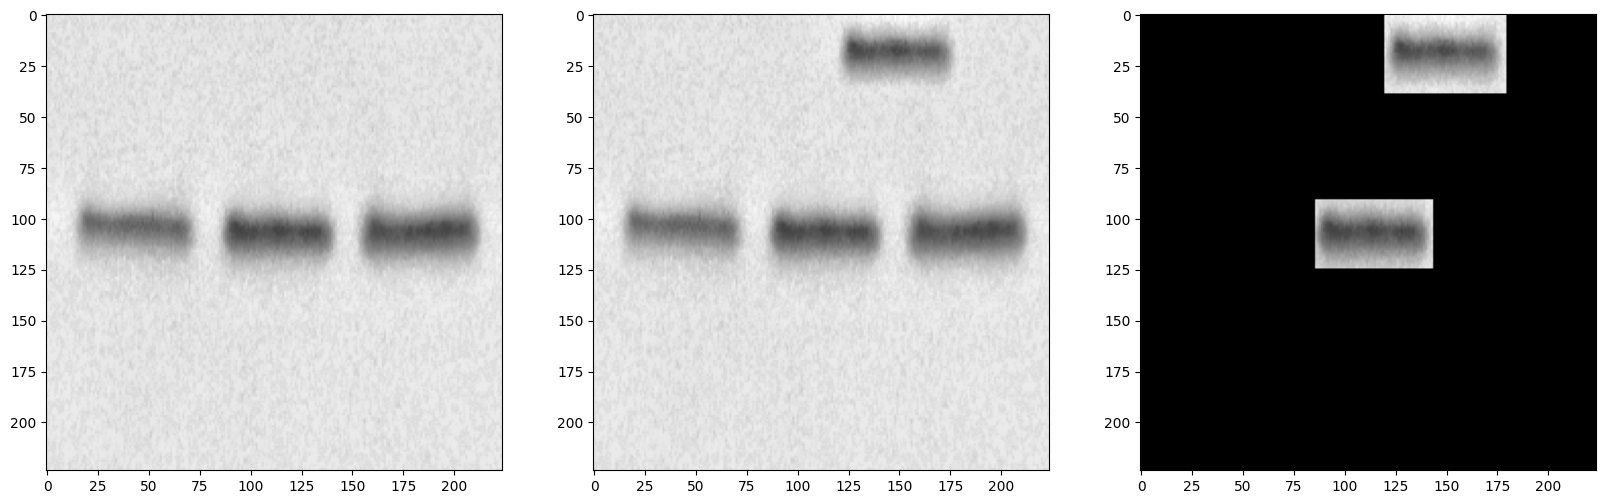

In [ ]:
test_img_pth = "55072.png"
fake_img_pth = os.path.join(FORGED_DIR, test_img_pth)
real_img_pth = os.path.join(AUTHENTIC_DIR, test_img_pth)
IMG_SIZE = 224

#read images,
real_img = cv.cvtColor(cv.imread(real_img_pth), cv.COLOR_BGR2LAB)
fake_img = cv.cvtColor(cv.imread(fake_img_pth), cv.COLOR_BGR2LAB)


#mask
mask_pth = os.path.join(MASK_DIR, f"{test_img_pth.split('.')[0]}.npy")
mask = np.load(mask_pth).squeeze()

#resize
fake_img = cv.resize(fake_img, (IMG_SIZE, IMG_SIZE))
real_img = cv.resize(real_img, (IMG_SIZE, IMG_SIZE))
mask = cv.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv.INTER_NEAREST)

#Transformation
l1,a1,b1= cv.split(fake_img)
l2,a2,b2= cv.split(real_img)
clahe = cv.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
l1 = clahe.apply(l1)
l2 = clahe.apply(l2)

fake_img = cv.merge((l1,a1,b1))
real_img = cv.merge((l2,a2,b2))

fake_img = cv.cvtColor(fake_img, cv.COLOR_LAB2BGR)
real_img = cv.cvtColor(real_img, cv.COLOR_LAB2BGR)


# fake_img = cv.equalizeHist(fake_img)
# real_img = cv.equalizeHist(real_img)
masked_img = cv.bitwise_and(fake_img, fake_img, mask=mask)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 10))
ax1.imshow(real_img, cmap="gray")
ax2.imshow(fake_img, cmap="gray")
ax3.imshow(masked_img, cmap="gray")
plt.show()

## Methods

- Our Initial approach will take the DINOv2 ViT with additional feature based detection methods and openCv processsing to output a basic highlihted region for suspicious regions.

Detail Each step of this method:
....
...


- Following methods will include hybrid based architecture employing the ViT pre-trained encoder and CNN based decoder for more advanced localization. These will include novel approaches combining techniques of different CMF detection algorithms.

- The ViT alone produces embeddings for classification tasks, we need a segmentation head to solve our problem.

- While pure ViTs work well for segmentation, hybrid models combine CNNs and Transformers. The initial layers can be CNNs, which extract low-level features and reduce the image resolution, followed by a Transformer to capture high-level dependencies. This approach offers the best of both worlds: CNNs for local feature extraction and Transformers for long-range context understanding.


Information:
- https://medium.com/@ankitrajsh/image-segmentation-using-vision-transformers-vit-a-deep-dive-with-cityscapes-and-camvid-datasets-fc1ccdca295b

- https://huggingface.co/learn/computer-vision-course/en/unit3/vision-transformers/vision-transformers-for-image-segmentation

- https://medium.com/data-science/efficient-image-segmentation-using-pytorch-part-4-6c86da083432

- https://www.nature.com/articles/s41598-025-93353-2

- https://www.sciencedirect.com/science/article/pii/S0010482523013239#:~:text=Then%2C%20the%20Transformer%20module%20will,the%20original%20image%20size%2C%20respectively.

- https://www.geeksforgeeks.org/machine-learning/what-are-convolution-layers/

- https://www.geeksforgeeks.org/deep-learning/cnn-introduction-to-pooling-layer/

- https://www.kaggle.com/code/djamilabenchikh/cnn-dinov2-hybrid

- https://arxiv.org/abs/2105.01152

- https://arxiv.org/abs/2112.01527

- https://huggingface.co/docs/transformers/en/model_doc/segformer

---


- Moment based methods:
  - scheme based circular matching using Hu moments.



In [ ]:
def preprocess_image(self, image_path):
  # Read the image
  img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

  # Convert white pixels to black
  img[img == 255] = 0


  ## Random spin of the image
  angle = random.randint(0, 360)  # Generate random angle between 0 and 360 degrees
  rows, cols = img.shape[:2]
  M = cv.getRotationMatrix2D((cols/2, rows/2), angle, 1)  # Get rotation matrix
  img = cv.warpAffine(img, M, (cols, rows))  # Apply rotation

  # Optional: Normalize the image
  cleaned_image = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX)

  # Convert white pixels to black again (in case normalization created new white pixels)
  cleaned_image[cleaned_image == 255] = 0

# Pytorch CustomDataset and Dataloader
Next Create Pytorch custome dataset and data loader classes for streamlined data processing.

- Building a full transformer is beyond the scope of the project.
- We will utilize transfer learning and a customized segmentation head to perform image segmentation.
- CNN Model: maskrcnn_resnet50_fpn(pretrained=True)

- (data ingestion/transformations)
  - Load in the data for pytorch processing.
  - Grayscale
  - Rotations
  - etc.


In [ ]:
import logging
from PIL import Image
from sklearn.model_selection import train_test_split
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
#Pytorch Device Agnostic
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 16

def apply_clahe(img):
  img = np.array(img)
  img = cv.cvtColor(img, cv.COLOR_BGR2LAB)
  l1,a1,b1= cv.split(img)
  clahe = cv.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
  l1 = clahe.apply(l1)
  img = cv.merge((l1,a1,b1))
  img = cv.cvtColor(img, cv.COLOR_LAB2BGR)
  return Image.fromarray(img)


class BioMedicalData(Dataset):
  #Constructor
  def __init__(self, forged_pths, authentic_pths, mask_dir, transform=None):
    self.forged_pths = forged_pths
    self.authentic_pths = authentic_pths
    self.mask_dir = mask_dir
    self.transform = transform
    self.data = []
    #generate list of paths
    for img in forged_pths:
      mask = os.path.join(mask_dir, os.path.basename(img).split('.')[0]+".npy")
      if os.path.exists(mask):
        self.data.append((img, mask))

    for img in authentic_pths:
        self.data.append((img, None))

  #support len function
  def __len__(self):
    return len(self.data)


  #Support indexing
  def __getitem__(self, idx):
    #read_img
    logger.info("get item called")
    img_path, mask_path = self.data[idx]
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    if mask_path is None:
        mask = np.zeros((h, w), np.uint8)
    else:
      #Handle Multiple Masks/different formatting
        m = np.load(mask_path)
        if m.ndim == 3:
          m = np.max(m, axis=0)
        mask = (m > 0).astype(np.uint8) #binary mask conversion.
    #Image Transformations
    img_r = img.resize((IMG_SIZE, IMG_SIZE))
    mask_r = cv.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv.INTER_NEAREST)
    img_r = apply_clahe(img_r)

    img_t = torch.from_numpy(np.array(img_r, np.float32)/255.).permute(2,0,1)
    mask_t = torch.from_numpy(mask_r[None, ...].astype(np.float32))
    return img_t, mask_t



#ADD TO THIS FOR YOUR USECASE/TASK

#split 80/20
auth_paths = sorted([os.path.join(AUTHENTIC_DIR, img_file) for img_file in os.listdir(AUTHENTIC_DIR)])
forg_paths = sorted([os.path.join(FORGED_DIR, img_file) for img_file in os.listdir(FORGED_DIR)])

train_auth, val_auth = train_test_split(auth_paths, test_size = .2, random_state = 42)
train_forg, val_forg = train_test_split(forg_paths, test_size = .2, random_state = 42)


train_dataset = BioMedicalData(train_forg, train_auth, MASK_DIR)
val_dataset = BioMedicalData(val_forg, val_auth, MASK_DIR)



train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                        shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=True, num_workers=2)


#Ensure dataset is proper

In [ ]:
print(len(train_dataset), len(val_dataset))
testing_img, testing_mask= train_dataset[25]

4101 1027


(224, 224, 3)

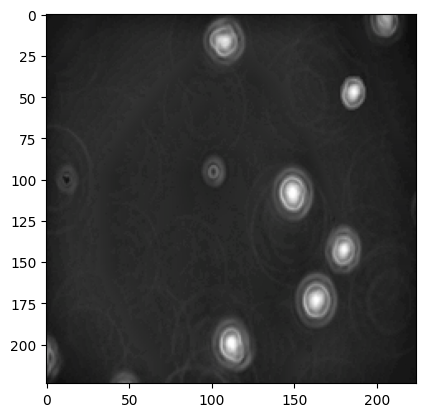

In [ ]:
image = testing_img.permute(1,2,0).numpy()
plt.imshow(image, cmap='gray')
image.shape

In [ ]:
testing_mask.shape

torch.Size([1, 224, 224])

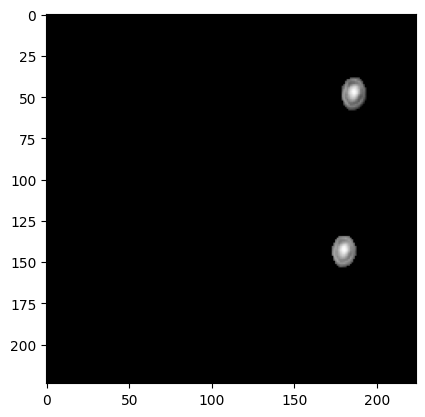

In [ ]:
mask_np = testing_mask.squeeze().cpu().numpy().astype(np.uint8)
masked_img = cv.bitwise_and(image, image, mask=mask_np)
plt.imshow(masked_img, 'gray')

# ViT
1. Vision Transformer Encoder (DINOv2)
  - Splits the image into patches
  - Embeds them
  - Passes them through transformer layers
  - Outputs a sequence of patch embeddings
(e.g., 768-dim per patch for ViT-base)

2. Simple Segmentation Head (linear projection)
  - Likely a small MLP or 1×1 convolution that maps patch embeddings → mask.


In [ ]:
# Load model directly
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base") #
model = AutoModel.from_pretrained("facebook/dinov2-base") #encoder needed

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
from transformers import Dinov2Model

# #DINO outputs 768-dimensional patch embeddings.
class DINOv2Segmentation(nn.Module):
    def __init__(self, model, processor, output_ch=1):
        super().__init__()

        #Feature extractor
        self.backbone = model.eval()
        self.processor = processor
        #freeze model encoder
        for param in self.backbone.parameters():
            param.requires_grad = False

        #passed to return prediction
        self.mask_head =nn.Sequential(
            nn.Conv2d(768, 256, 3, padding=1), #768, kernal 3x3, -> 256 output
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 1, 1)
        )
    #prediction mask
    def forward(self, x):
      #pass through model layers
      feat = self.backbone(pixel_values=x).last_hidden_state
      B, N, C = feat.shape
      # N = 1 + H*W tokens
      feat = feat[:, 1:, :]
      # remove CLS token
      H = W = int((N-1)**0.5)
      feat = feat.permute(0,2,1).reshape(B, C, H, W)
      mask = self.mask_head(feat) # (B,1,H,W) #upsample prediction mask
      mask = F.interpolate(mask, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
      return mask


In [ ]:
seg_model = DINOv2Segmentation(model, processor).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(seg_model.parameters(), lr=1e-4, fused=False)
LR_SEG = 1e-5
WEIGHT_DECAY = 2e-5
NUM_EPOCHS = 20


#Break --- Testing


In [ ]:
class ViTUNetDecoder(nn.Module):
    def __init__(self, embed_dim=768, out_ch=1):
        super().__init__()

        # Create 3 synthesized skip levels
        # ViT only outputs one feature map → so we simulate hierarchical features
        self.skip1 = nn.Conv2d(embed_dim, 512, kernel_size=1)
        self.skip2 = nn.Conv2d(embed_dim, 256, kernel_size=1)
        self.skip3 = nn.Conv2d(embed_dim, 128, kernel_size=1)

        self.up1 = nn.ConvTranspose2d(embed_dim, 512, kernel_size=2, stride=2)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)

        self.dec1 = self._block(512 + 512, 512)
        self.dec2 = self._block(256 + 256, 256)
        self.dec3 = self._block(128 + 128, 128)

        self.final = nn.Conv2d(128, out_ch, kernel_size=1)

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def _align(self, x, target):
        """Resize x to match target spatial size."""
        if x.shape[-2:] != target.shape[-2:]:
            x = F.interpolate(
                x, size=target.shape[-2:], mode="bilinear", align_corners=False
            )
        return x

    def forward(self, fmap):
        """
        fmap: (B, 768, H, W) from DINOv2
        """

        # Synthesized hierarchical features
        x1 = self.skip1(fmap)      # (B,512,H,W)
        x2 = self.skip2(fmap)      # (B,256,H,W)
        x3 = self.skip3(fmap)      # (B,128,H,W)

        # Decode
        u1 = self.up1(fmap)        # (B,512,2H,2W)
        u1 = self._align(u1, x1)
        u1 = self.dec1(torch.cat([u1, x1], dim=1))

        u2 = self.up2(u1)          # (B,256,4H,4W)
        u2 = self._align(u2, x2)
        u2 = self.dec2(torch.cat([u2, x2], dim=1))

        u3 = self.up3(u2)          # (B,128,8H,8W)
        u3 = self._align(u3, x3)
        u3 = self.dec3(torch.cat([u3, x3], dim=1))

        mask = self.final(u3)
        return mask

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class DinoDecoder(nn.Module):
    """Improved decoder: Conv + BN + ReLU blocks."""
    def __init__(self, in_ch=768, out_ch=1):
        super().__init__()
        self.decode = nn.Sequential(
            nn.Conv2d(in_ch, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, out_ch, 1)
        )

    def forward(self, x):
        return self.decode(x)


class DINOv2Segmentation(nn.Module):
    def __init__(self, model, processor, output_ch=1,
                 fine_tune_last_blocks=0):
        """
        fine_tune_last_blocks = number of final transformer blocks to unfreeze
        """
        super().__init__()

        # Backbone encoder
        self.backbone = model.eval()
        self.processor = processor

        # Freeze full model first
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Optionally unfreeze last N blocks (light finetuning boost!)
        if fine_tune_last_blocks > 0:
            total = len(self.backbone.encoder.layers)
            for blk in range(total - fine_tune_last_blocks, total):
                for p in self.backbone.encoder.layers[blk].parameters():
                    p.requires_grad = True

        # Decoder
        self.mask_head = ViTUNetDecoder(768, output_ch)

    def forward(self, x):
        B, C, Horig, Worig = x.shape

        # Convert to uint8 HWC images
        imgs = (x * 255).clamp(0,255).byte().permute(0,2,3,1).cpu().numpy()

        # Processor → ViT pixel_values
        inputs = self.processor(images=list(imgs), return_tensors="pt").to(x.device)

        # Extract token features
        with torch.no_grad():
            out = self.backbone(**inputs)
            tokens = out.last_hidden_state   # (B, 1 + HW, 768)

        # Remove CLS token
        tokens = tokens[:, 1:, :]

        # Check H/W derived from tokens
        N = tokens.shape[1]
        S = int(math.sqrt(N))
        fmap = tokens.permute(0, 2, 1).reshape(B, 768, S, S)

        # Decode into segmentation mask
        mask = self.mask_head(fmap)

        # Upsample to original input size
        mask = F.interpolate(mask, size=(Horig, Worig),
                             mode="bilinear", align_corners=False)
        return mask

In [ ]:
def train_segmentation(
    seg_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=20,
    scheduler=None,
    use_amp=False,
    save_path="best_seg_model.pth"
):
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_val_loss = float("inf")

    seg_model.to(device)

    for epoch in range(num_epochs):
        print(f"\n----- Epoch {epoch+1}/{num_epochs} -----")


        seg_model.train()
        train_loss = 0.0

        for imgs, masks in tqdm(train_loader, desc="Training", leave=False):
            imgs = imgs.to(device)            # (B,3,H,W)
            masks = masks.to(device)          # (B,1,H,W) or (B,H,W)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                preds = seg_model(imgs)       # (B,1,H,W)
                loss = criterion(preds, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ---------------------------
        # 📉 VALIDATION LOOP
        # ---------------------------
        seg_model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc="Validation", leave=False):
                imgs = imgs.to(device)
                masks = masks.to(device)

                with torch.cuda.amp.autocast(enabled=use_amp):
                    preds = seg_model(imgs)
                    loss = criterion(preds, masks)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        # Step LR scheduler
        if scheduler:
            scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(seg_model.state_dict(), save_path)
            print(f"✔ Saved new best model (loss={best_val_loss:.4f})")

    print("\nTraining complete!")

train_segmentation(seg_model, train_loader, val_loader, criterion, optimizer, device)

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_prediction(seg_model, dataset, device, idx=0):
    seg_model.eval()

    img, mask = dataset[idx]
    img_t = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = seg_model(img_t)          # (1,1,H,W)
        pred = torch.sigmoid(pred)       # convert logits → probabilities
        pred = (pred > 0.5).float()      # threshold

    pred_mask = pred.squeeze().cpu().numpy()
    gt_mask = mask.squeeze().cpu().numpy()
    img_np = img.permute(1,2,0).cpu().numpy()

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img_np); plt.title("Image")
    plt.subplot(1,3,2); plt.imshow(gt_mask, cmap="gray"); plt.title("Ground Truth")
    plt.subplot(1,3,3); plt.imshow(pred_mask, cmap="gray"); plt.title("Prediction")
    plt.show()

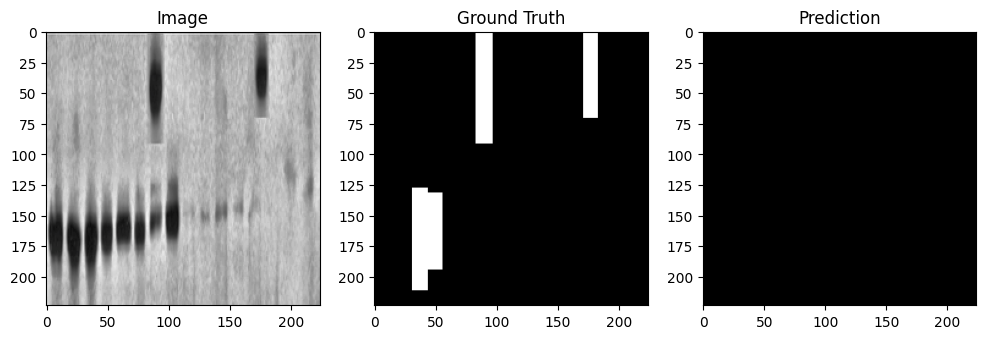

In [ ]:
visualize_prediction(seg_model, val_dataset, device,100)

#Break --- Testing


In [ ]:
from tqdm import tqdm
seg_model = DINOv2Segmentation(model, processor).to(device)
for epoch in range(NUM_EPOCHS):
    seg_model.train()
    total_loss = 0

    for imgs, masks in tqdm(train_loader):

        imgs = imgs.to(device)                  # (B,3,H,W)
        masks = masks.to(device)                # (B,1,H,W)

        optimizer.zero_grad()

        pred_masks = seg_model(imgs)                # (B,1,H,W)
        loss = criterion(pred_masks, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")


100%|██████████| 257/257 [01:44<00:00,  2.46it/s]


Epoch 1 Loss: 0.7298


100%|██████████| 257/257 [01:42<00:00,  2.52it/s]


Epoch 2 Loss: 0.7297


100%|██████████| 257/257 [01:43<00:00,  2.49it/s]


...

Epoch 4 Loss: 0.7296


100%|██████████| 257/257 [01:43<00:00,  2.48it/s]


Epoch 5 Loss: 0.7296


 67%|██████▋   | 172/257 [01:08<00:34,  2.50it/s]


KeyboardInterrupt: 

In [ ]:
torch.save(seg_model.state_dict(),"dh_seg_v1.pt")
seg_model.eval()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/dh_seg_v1.pt /content/drive/MyDrive/ModelWeights/dh_seg_v1.pt

In [ ]:
from PIL import Image
import torch
import matplotlib.pyplot as plt
test_img_pth = "55072.png"
fake_img_pth = os.path.join(FORGED_DIR, test_img_pth)
img = Image.open(fake_img_pth).convert("RGB")
inputs = processor(images=img, return_tensors="pt")
pixel_values = inputs.pixel_values.to(device)

with torch.no_grad():
    pred_mask = seg_model(pixel_values)   # shape (1,1,224,224)
    pred_mask = torch.sigmoid(pred_mask)  # convert logits → probability
    pred_mask = pred_mask.squeeze().cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(pred_mask, cmap="gray")
plt.axis("off")

plt.show()